## 1. Import Required Libraries

In [1]:
#from hetgpy import hetGP
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# For reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Data

Load pre-generated training and test data from numpy files.

In [3]:
def get_files(indir, file_names, suffix=None):
    """
    Load numpy files from a directory.
    
    Parameters
    ----------
    indir : Path
        Directory containing files
    file_names : list
        List of file base names (without .npy extension)
    suffix : str, optional
        Suffix to append to each filename
    
    Returns
    -------
    dict
        Dictionary with file_name as key and loaded array as value
    """
    data = {}
    for file_name in file_names:
        if suffix is not None:
            get_name = file_name + suffix
        else:
            get_name = file_name
        load_in = np.load(indir / f"{get_name}.npy")
        data[file_name] = load_in
    return data


# Load data
EXP_NAME = "exp_k25_n2"
indir = Path(EXP_NAME + "/Input")
m = 40  # Macro replicate index

# Load training data for macro replicate m
train_data = get_files(indir, ['train_x', 'train_y'], suffix=f'_m{m}')

# Load test data (shared across all macros)
test_data = get_files(indir, ['test_x', 'test_y', 'test_sigma2'])

# Load predictions 
indir = Path(EXP_NAME + "/Data")
names = ['pred_f','pred_sigma2_eps','pred_sigma2_f']

pred_data = get_files(indir, names, suffix=f"_m{m}")

print(f"Training data loaded:")
print(f"  X shape: {train_data['train_x'].shape}")
print(f"  Y shape: {train_data['train_y'].shape}")
print(f"\nTest data loaded:")
print(f"  X shape: {test_data['test_x'].shape}")
print(f"  Y shape: {test_data['test_y'].shape}")
print(f"  Sigma2 shape: {test_data['test_sigma2'].shape}")
print(f"\nPrediction data loaded:")
print(f"  pred_f shape: {pred_data['pred_f'].shape}")
print(f"  pred_sigma2_eps shape: {pred_data['pred_sigma2_eps'].shape}")
print(f"  pred_sigma2_f shape: {pred_data['pred_sigma2_f'].shape}")


Training data loaded:
  X shape: (50, 1)
  Y shape: (50, 1)

Test data loaded:
  X shape: (200, 1)
  Y shape: (200, 1)
  Sigma2 shape: (200, 1)

Prediction data loaded:
  pred_f shape: (200,)
  pred_sigma2_eps shape: (200,)
  pred_sigma2_f shape: (200,)


## 4. Make Predictions

Predict on a test grid and extract:
- **mean**: Predicted function value
- **sd2**: Epistemic uncertainty (model uncertainty)
- **nugs**: Aleatoric uncertainty (noise variance prediction)

## 5. Visualization: Sausage Plot

Create a comprehensive visualization showing:
- Training observations
- Predicted mean
- True function
- Epistemic uncertainty bands
- Aleatoric (noise) uncertainty bands
- True noise variance

In [4]:
# Plotting parameters
DPI = 300
FIGSIZE = (14, 9)

def sausage_plot(
    train_x,
    train_y,
    grid_x,
    pred_f,
    pred_sigma2_f,
    pred_sigma2_eps,
    true_f,
    true_sigma2,
    path=None,
    f_name=None,
    plot_title="Predictions",
):
    """
    Create a 'sausage plot' showing predictions with uncertainty bands.
    
    This visualization includes:
    - Posterior mean prediction
    - Model uncertainty (epistemic)
    - Noise uncertainty (aleatoric)
    - True function and true noise level (if available)
    """
    fig, ax = plt.subplots(1, 1, figsize=FIGSIZE, dpi=100)
    
    # Plot observations
    ax.scatter(train_x, train_y, s=50, alpha=0.6, label="Evals", color="C0", edgecolors='black', linewidth=0.5)
    
    # Plot predicted mean
    ax.plot(grid_x, pred_f, color="C0", linewidth=2, label="Post Mean")
    
    # Plot true function
    ax.plot(grid_x, true_f, color='g', linewidth=2, label='Truth')
    
    # Plot epistemic uncertainty (model uncertainty)
    ax.fill_between(
        grid_x.squeeze(),
        pred_f - 2 * np.sqrt(pred_sigma2_f),
        pred_f + 2 * np.sqrt(pred_sigma2_f),
        color="C0",
        alpha=0.25,
        label="±2 std σ_f (epistemic)",
    )
    
    # Plot aleatoric uncertainty (noise)
    ax.fill_between(
        grid_x.squeeze(),
        pred_f - 2 * np.sqrt(pred_sigma2_eps),
        pred_f + 2 * np.sqrt(pred_sigma2_eps),
        color="C1",
        alpha=0.25,
        label="±2 std σ_ε (aleatoric)",
    )
    
    # Plot true noise level
    ax.fill_between(
        grid_x.squeeze(),
        true_f - 2 * np.sqrt(true_sigma2),
        true_f + 2 * np.sqrt(true_sigma2),
        color="C2",
        alpha=0.25,
        label="±2 std (truth)",
    )
    
    # Configure plot
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.set_title(plot_title, fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save if path provided
    if path is not None and f_name is not None:
        path = Path(path)
        path.mkdir(parents=True, exist_ok=True)
        plt.savefig(path / f_name, dpi=DPI, bbox_inches='tight')
        print(f"Plot saved to: {path / f_name}")
    
    #plt.show()
    #return fig, ax

# outdir = Path(EXP_NAME + "/Analysis")
# indir = Path(EXP_NAME + "/Input")
# test_data = get_files(indir, ['test_x', 'test_y', 'test_sigma2'])
# M=50
# for m in range(0,M):
# 	# Load training data for macro replicate m
# 	indir = Path(EXP_NAME + "/Input")
# 	train_data = get_files(indir, ['train_x', 'train_y'], suffix=f'_m{m}')

# 	# Load test data (shared across all macros)
	

# 	# Load predictions 
# 	indir = Path(EXP_NAME + "/Data")
# 	names = ['pred_f','pred_sigma2_eps','pred_sigma2_f']

# 	pred_data = get_files(indir, names, suffix=f"_unstd_m{m}")

# 	# Create the sausage plot
# 	sausage_plot(
# 		train_data['train_x'].squeeze(),
# 		train_data['train_y'].squeeze(),
# 		test_data['test_x'].squeeze(),
# 		pred_data['pred_f'].squeeze(),
# 		pred_data['pred_sigma2_f'].squeeze(),
# 		pred_data['pred_sigma2_eps'].squeeze(),
# 		test_data['test_y'].squeeze(),
# 		test_data['test_sigma2'].squeeze(),
# 		path=outdir,
# 		f_name=f"data_fit_hetgpy_m{m}.png",
# 		plot_title=f"hetGPy Heteroscedastic GP - m={m}",
# 	)
	

In [5]:
from hetgp_exp_utils import HetGP_Model

model_wrapper = HetGP_Model()
hyperparameters = model_wrapper.fit(
    train_x=train_data['train_x'],
    train_y=train_data['train_y'],
    standardise=False
)



Test: 0.10886141589204681 is <class 'float'>


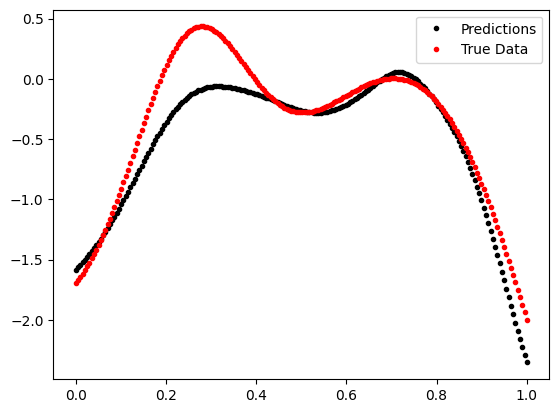

In [17]:
preds = model_wrapper.predict(test_data['test_x'])

plt.plot(test_data['test_x'], preds['mean'], 'k.', label='Predictions')
plt.plot(test_data['test_x'], test_data['test_y'], 'r.', label='True Data')
plt.legend()

In [ ]:
import numpy as np
from scipy.integrate import simpson
from scipy.optimize import bisect
from scipy.stats import norm

#TODO Gumbel fit method
#TODO Gumbel predict method

def _fit_gumbel(fmean, fsd):
    """
    Helper function to fit gumbel distribution when initialising the MES and MUMBO acquisition functions.

    The Gumbel distribution for minimas has a cumulative density function of f(y)= 1 - exp(-1 * exp((y - a) / b)), i.e. the q^th quantile is given by
    Q(q) = a + b * log( -1 * log(1 - q)). We choose values for a and b that match the Gumbel's
    interquartile range with that of the observed empirical cumulative density function of Pr(y*<y)
    i.e.  Pr(y* < lower_quantile)=0.25 and Pr(y* < upper_quantile)=0.75.
    """
	#TODO Edit to sample max values instead of min

	#CORRECT, but I standardise, in botorch they don't 
    def probf(x: np.ndarray) -> float:
        # Build empirical CDF function
        return np.exp(np.sum(norm.logcdf((x - fmean) / fsd), axis=0))

    # initialise end-points for binary search (the choice of 5 standard deviations ensures that these are outside the IQ range)
    left = np.min(fmean - 3 * fsd) #minux 3 for some reason on botorch?
    right = np.max(fmean + 5 * fsd)

    def binary_search(val: float) -> float:
        return bisect(lambda x: probf(x) - val, left, right, maxiter=10000)

    # Binary search for 3 percentiles
    lower_quantile, medium, upper_quantile = map(binary_search, [0.25, 0.5, 0.75])

    # solve for Gumbel scaling parameters CORRECT
    b = (lower_quantile - upper_quantile) / (np.log(np.log(4.0 / 3.0)) - np.log(np.log(4.0)))
    a = medium + b * np.log(np.log(2.0))

    return a, b

class MUMBO():

	def __init__(self,
					model,
					bounds = [0,1],
					max_value_samples = 10,
					grid_size = 40):
		
		self.model = model
		self.bounds = bounds   
		self.max_value_samples = max_value_samples
		self.grid_size = grid_size
		self.mvs = None

	def _required_parameters_initialized(self):
		"""
		Checks if all required parameters are initialized.
		"""
		return self.mvs is not None

	def update_parameters(self):
		"""
		MUMBO requires acces to a sample of possible minimum values y* of the objective function.
		To build this sample we approximate the empirical c.d.f of Pr(y*<y) with a Gumbel(a,b) distribution.
		This Gumbel distribution can then be easily sampled to yield approximate samples of y*

		This needs to be called once at the start of each BO step.
		"""
		
		grid = np.linspace(self.bounds[0],self.bounds[1],self.grid_size)
		grid = np.expand_dims(grid,axis=1)

		#Concatinate evenly space grid and 
		grid = np.vstack([self.model.model['X0'],grid])

		preds = self.model.predict(grid)

		mean_f = preds['mean']
		sd_f = np.sqrt(preds['sd2'])

		a, b = _fit_gumbel(mean_f,sd_f)

		uniform_samples = np.random.rand(self.max_value_samples)
		gumbel_samples = -np.log(-np.log(uniform_samples)) * b + a

		self.mvs = gumbel_samples

	def evaluate(self,x):
		"""
		Evaluate the MUMBO acquisition function at a given point x.
		
		Parameters
		----------
		x : ndarray
			Input location (shape: (m,d+1))
		
		Returns
		-------
		float
			Value of the MUMBO acquisition function at x
		"""
		#Calculates max value samples if None
		if not self._required_parameters_initialized():
			self.update_parameters()
		
		#Extract replication index
		n = x[:, -1].astype(int).reshape(-1,1)
		x = x[:, :-1]
		
		print("The x shape is: ", x.shape)
		print("The n shape is: ", n.shape)

		# Get predictive mean and variance from the model
		preds = self.model.predict(x)   

		mean_f = preds["mean"].reshape(-1,1)
		var_f = preds['sd2'].reshape(-1,1) 
		mean_eps = preds['nugs'].reshape(-1,1)

		std_f = np.sqrt(var_f)
		std_f = np.maximum(std_f, 1e-10)  # Avoid division by zero

		#Calculate Correlation Term
		rho = np.sqrt(n) * std_f / np.sqrt(n * var_f + mean_eps)
		
		gammas = (self.mvs - mean_f) / std_f

		ESGmean = rho * norm.pdf(gammas) / norm.cdf(gammas)
		ESGvar = 1 - rho * ESGmean * (gammas + norm.pdf(gammas)/norm.cdf(gammas))
		ESGvar = np.maximum(ESGvar,0)


		upper_limit = ESGmean + 8 * np.sqrt(ESGvar)
		lower_limit = ESGmean - 8 * np.sqrt(ESGvar)

		theta = np.linspace(lower_limit,upper_limit,num = 5000)
		print("the shape of theta is", theta.shape)
		denominator = np.sqrt(1 - rho**2)

		density = norm.pdf(theta) * (norm.cdf((gammas - rho * theta)/denominator))/norm.cdf(gammas)
		print("the density shape is: ", density.shape)
		
		entropy_function = -density * np.log(density,out=np.zeros_like(density), where=(density != 0))

		approx_entropy = simpson(entropy_function.T,x=theta.T)
		#print(approx_entropy)
		#print("The approx_entropy shape is: ", approx_entropy.shape)
		approx_entropy = np.mean(approx_entropy,axis = 0)

		f_acqu_x = 0.5 *np.log(2*np.pi*np.e) - approx_entropy

		#Hard Code for now
		b0 = 1
		b1 = 0.5

		cost = 1/(b0 + n*b1)
		#cost = 1
		#print("The cost shape is: ", cost.shape)
		#print("The f_acqu_x shape is: ", f_acqu_x.shape)
		f_acqu_x= f_acqu_x.reshape(-1,1) * cost
		return f_acqu_x.reshape(-1,1)
	
	def evaluate_alternative_formulation(self,x):
		"""
		Evaluate the MUMBO acquisition function at a given point x.
		
		Parameters
		----------
		x : ndarray
			Input location (shape: (m,d+1))
		
		Returns
		-------
		float
			Value of the MUMBO acquisition function at x
		"""
		#Calculates max value samples if None
		if not self._required_parameters_initialized():
			self.update_parameters()
		
		#Extract replication index
		n = x[:, -1].astype(int).reshape(-1,1)
		x = x[:, :-1]
		
		print("The x shape is: ", x.shape)
		print("The n shape is: ", n.shape)

		# Get predictive mean and variance from the model
		preds = self.model.predict(x)   

		mean_f = preds["mean"].reshape(-1,1)
		var_f = preds['sd2'].reshape(-1,1) 
		mean_eps = preds['nugs'].reshape(-1,1)

		std_f = np.sqrt(var_f)
		std_f = np.maximum(std_f, 1e-14)  # Avoid division by zero

		#Calculate Correlation Term
		rho = np.sqrt(n) * std_f / np.sqrt(n * var_f + mean_eps)
		gammas = (self.mvs - mean_f) / std_f

		gamma_cdf = norm.cdf(gammas)
		gamma_pdf = norm.pdf(gammas)

		first_term = (gammas*gamma_pdf*rho**2) / (2 * gamma_cdf) -np.log(gamma_cdf)

		ESGmean = rho * (norm.pdf(gammas)) / norm.cdf(gammas)
		ESGvar = 1 - rho * ESGmean * (gammas + norm.pdf(gammas)/norm.cdf(gammas))
		ESGvar = np.maximum(ESGvar,0)

		upper_limit = ESGmean + 8 * np.sqrt(ESGvar)
		lower_limit = ESGmean - 8 * np.sqrt(ESGvar)

		theta = np.linspace(lower_limit,upper_limit,num = 10000)
		
		denominator = np.sqrt(1 - rho**2)
		ESG_density = norm.pdf(theta) * (norm.cdf((gammas - rho * theta)/denominator))/norm.cdf(gammas)

		inner_term = norm.cdf((gammas - rho * theta)/denominator)
		integral = ESG_density*np.log(inner_term,out=np.zeros_like(inner_term), where=(inner_term != 0))
		approx_entropy = simpson(integral.T,x=theta.T)

		#approx_entropy = np.mean(approx_entropy,axis = 0)
		print("The first_term shape is: ", first_term.shape)
		print("The approx_entropy shape is: ", approx_entropy.shape)

		alpha = first_term.T + approx_entropy
		print(approx_entropy)
		alpha = np.mean(alpha,axis = 0)
		#cost = 1/n
		cost = 1
		#print("The cost shape is: ", cost.shape)
		#print("The f_acqu_x shape is: ", f_acqu_x.shape)
		alpha= alpha.reshape(-1,1) * cost
		
		return alpha.reshape(-1,1)


In [26]:
acqf = MUMBO(model_wrapper)
n =5
x_test = np.linspace(0.1,1,50)[:,None]
n = np.ones_like(x_test)* n  # Assuming one replicate for each test point
x_test = np.hstack((x_test, n))  # Concatenate to form (x, n) pairs
print(x_test.shape)
acqf_vals = acqf.evaluate(x_test)
acqf_vals_alternative = acqf.evaluate_alternative_formulation(x_test)

print("Acquisition function values (original):", acqf_vals)
print("Acquisition function values (alternative):", acqf_vals_alternative)

(50, 2)
The x shape is:  (50, 1)
The n shape is:  (50, 1)
the shape of theta is (5000, 50, 10)
the density shape is:  (5000, 50, 10)
The x shape is:  (50, 1)
The n shape is:  (50, 1)
The first_term shape is:  (50, 10)
The approx_entropy shape is:  (10, 50)
[[-1.21189604e-03 -2.27547390e-03 -4.15544850e-03 -7.15557599e-03
  -1.14123304e-02 -1.67140696e-02 -2.23963424e-02 -2.73923316e-02
  -3.04625978e-02 -3.05097220e-02 -2.69840993e-02 -2.05149528e-02
  -1.30507906e-02 -6.83382794e-03 -2.96493559e-03 -1.10927477e-03
  -3.84069100e-04 -1.37357230e-04 -5.86794759e-05 -3.15195606e-05
  -1.76590585e-05 -7.50119834e-06 -1.86855861e-06 -2.49354345e-07
  -2.15281278e-08 -1.69203826e-09 -9.96956544e-11 -1.48557061e-12
  -1.10597642e-15 -7.19969717e-21 -1.70660787e-31  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00 -1.08368984e-26 -1.73824652e-16 -5.24092479e-13
  -3.25440109e-12 -5.36130553e-13 -7.56673990e-15 -3.60621637e-17
  -2.54176665e-19

(100, 2)
The x shape is:  (100, 1)
The n shape is:  (100, 1)
the shape of theta is (5000, 100, 10)
the density shape is:  (5000, 100, 10)
The x shape is:  (100, 1)
The n shape is:  (100, 1)
the shape of theta is (5000, 100, 10)
the density shape is:  (5000, 100, 10)
The x shape is:  (100, 1)
The n shape is:  (100, 1)
the shape of theta is (5000, 100, 10)
the density shape is:  (5000, 100, 10)
The x shape is:  (100, 1)
The n shape is:  (100, 1)
the shape of theta is (5000, 100, 10)
the density shape is:  (5000, 100, 10)
The x shape is:  (100, 1)
The n shape is:  (100, 1)
the shape of theta is (5000, 100, 10)
the density shape is:  (5000, 100, 10)
The x shape is:  (100, 1)
The n shape is:  (100, 1)
the shape of theta is (5000, 100, 10)
the density shape is:  (5000, 100, 10)


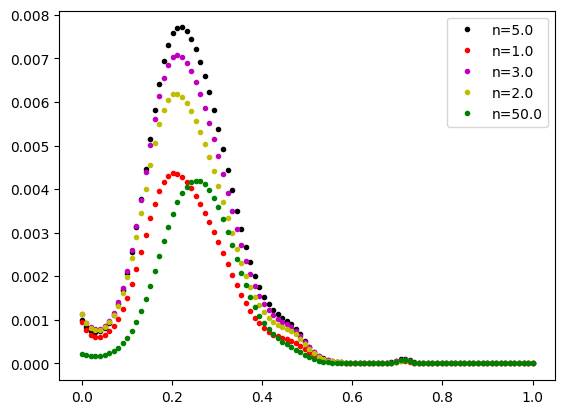

In [19]:
acqf = MUMBO(model_wrapper)
n =5
x_test = np.linspace(0,1,100)[:,None]
n = np.ones_like(x_test)* n  # Assuming one replicate for each test point
x_test = np.hstack((x_test, n))  # Concatenate to form (x, n) pairs
print(x_test.shape)
acqf_vals = acqf.evaluate(x_test)

plt.plot(x_test[:,0],acqf.evaluate(x_test),'k.',label = f'n={n[0,0]}')

n =1
x_test = np.linspace(0,1,100)[:,None]
n = np.ones_like(x_test)* n  # Assuming one replicate for each test point
x_test = np.hstack((x_test, n))  # Concatenate to form (x, n) pairs

plt.plot(x_test[:,0],acqf.evaluate(x_test),'r.',label = f'n={n[0,0]}')

n =3
x_test = np.linspace(0,1,100)[:,None]
n = np.ones_like(x_test)* n  # Assuming one replicate for each test point
x_test = np.hstack((x_test, n))  # Concatenate to form (x, n) pairs

plt.plot(x_test[:,0],acqf.evaluate(x_test),'m.',label = f'n={n[0,0]}')

n =2
x_test = np.linspace(0,1,100)[:,None]
n = np.ones_like(x_test)* n  # Assuming one replicate for each test point
x_test = np.hstack((x_test, n))  # Concatenate to form (x, n) pairs

plt.plot(x_test[:,0],acqf.evaluate(x_test),'y.',label = f'n={n[0,0]}')

n =50
x_test = np.linspace(0,1,100)[:,None]
n = np.ones_like(x_test)* n  # Assuming one replicate for each test point
x_test = np.hstack((x_test, n))  # Concatenate to form (x, n) pairs

plt.plot(x_test[:,0],acqf.evaluate(x_test),'g.',label = f'n={n[0,0]}')

plt.legend()

In [20]:
def input_generator(n_grid,bounds=[0,1],replications=None):
    """
    Should be able to also pass input to AF for different selections of n
    
    Optional boudns to be handled later
    """    

    #Includes n if replications is not none

    #Generate test points
    grid_x =  np.linspace(0,1,n_grid)

    # Generates grid of x and n values if replications given
    if replications is not None:
        grid_xn = np.stack([
            np.tile(grid_x,len(replications)),          # column 0
            replications.repeat(len(grid_x))  # column 1
        ], axis=1)

        #If replications supplied
        return {"xn":grid_xn,"x":grid_x.reshape(-1,1)}

    return grid_x.reshape(-1,1)

def acqf_plot(grid_xn,
              acq_vals,
              path,
              f_name,
              plot_title,):
	'''
	Plots the predicted intrinsic uncertainty (sigma^2_eps) and extrinsic uncertainty (sigma^2_f)
	of the Gaussian Process at a give iteration

	Inputs
	------
		N_points: Tensor
			Number of grid points to make prediction
		AF: AcquisitionFunction
			An initalised Acquisition Function
		n_vals: int Tensor
			Chosen n value 
		fig_title: String Optional[Default=None] 
			Title of the figure if needed.
		f_name: String Optional[Default=None]
			If a filename string is supplied the generated figure will be automatically saved under
			that name. Format must be supplied in f_name i.e. .png or .eps
		new_point: bool Optional[Default=False]
			Highlights the selected candidate if set to true
	'''


	# Initialize plot
	plt.figure(figsize=FIGSIZE)
	if isinstance(grid_xn,dict):
		#Get grids
		grid_x = grid_xn['x']
		grid_xn = grid_xn['xn']
		n_vals = np.unique(grid_xn[...,1])

		for i, n in enumerate(n_vals):
			plt.plot(grid_x,acq_vals[i],label=f"n={n}")
	else:

		plt.plot(grid_xn,acq_vals,label="AF")

	plt.xlabel('$x$')
	plt.ylabel('$AF(x)$')
	plt.title(plot_title)
	plt.legend()

	#Savefig at subdir: acqs w/name: acqf_acqs_m_t

	plt.savefig(path / f_name, dpi=DPI, bbox_inches="tight")
	plt.close()
    

def acqf_plotter(n_grid,
                 acq_func,
                 acqf_name,
                 path,
                 run_params=None,
                 replications=None
                 ):

	#Generate Grid
	grid_xn = input_generator(n_grid,replications=replications)

	#Obtain acqf values
	if replications is not None:
		acq_vals = acq_func(grid_xn['xn'])
		acq_vals = acq_vals.reshape(replications.shape[0],n_grid)
	else:
		acq_vals = acq_func(grid_xn)

	plot_title = "acq vals"

	if run_params is not None:
		plot_title = plot_title + f"|m={run_params['m']}|t={run_params['t']}|"
		f_name = f"{acqf_name}_acqf_{run_params['m']}_{run_params['t']}.png"
	else:
		f_name = f"{acqf_name}_acqf.png"

	outdir = Path(path +"/acqs")
	outdir.mkdir(parents=True, exist_ok=True)
	#Plot and save acq fig
	acqf_plot(grid_xn=grid_xn,
				acq_vals=acq_vals,
				path=outdir,
				f_name = f_name,
				plot_title=plot_title
				)

In [21]:
EXP_NAME = "DESBO_run"

Test: 0.29533828840187976 is <class 'float'>


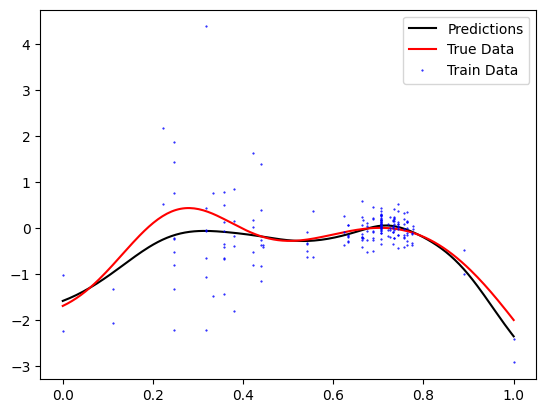

In [22]:
#outdir = Path(EXP_NAME + "/Analysis")
indir = Path(EXP_NAME + "/Input")
outdir = Path(EXP_NAME + "/Analysis")
outdir.mkdir(parents=True, exist_ok=True)
test_data = get_files(indir, ['test_x', 'test_y', 'test_sigma2'])
m=0

train_data = get_files(indir, ['train_x', 'train_y','train_n'], suffix=f'_m{m}')

model_wrapper = HetGP_Model()
hyperparameters = model_wrapper.fit(
    train_x=train_data['train_x'],
    train_y=train_data['train_y'],
    standardise=False
)
preds = model_wrapper.predict(test_data['test_x'])

plt.plot(test_data['test_x'], preds['mean'], 'k-', label='Predictions')
plt.plot(test_data['test_x'], test_data['test_y'], 'r-', label='True Data')
plt.plot(train_data['train_x'], train_data['train_y'], 'bo',markersize=0.5, label='Train Data')
plt.legend()

(100, 2)
The x shape is:  (100, 1)
The n shape is:  (100, 1)
the shape of theta is (5000, 100, 10)
the density shape is:  (5000, 100, 10)
The x shape is:  (100, 1)
The n shape is:  (100, 1)
the shape of theta is (5000, 100, 10)
the density shape is:  (5000, 100, 10)
The x shape is:  (100, 1)
The n shape is:  (100, 1)
the shape of theta is (5000, 100, 10)
the density shape is:  (5000, 100, 10)
The x shape is:  (100, 1)
The n shape is:  (100, 1)
the shape of theta is (5000, 100, 10)
the density shape is:  (5000, 100, 10)
The x shape is:  (100, 1)
The n shape is:  (100, 1)
the shape of theta is (5000, 100, 10)
the density shape is:  (5000, 100, 10)
The x shape is:  (100, 1)
The n shape is:  (100, 1)
the shape of theta is (5000, 100, 10)
the density shape is:  (5000, 100, 10)


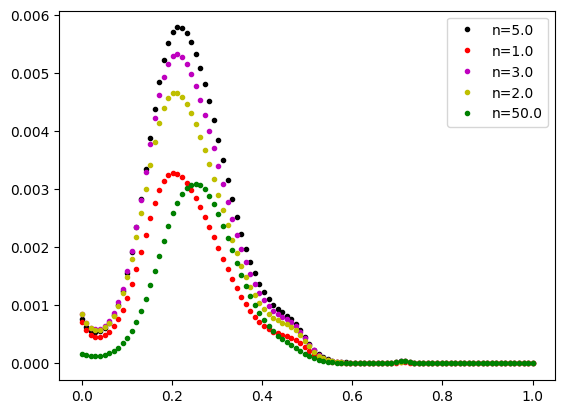

In [23]:
acqf = MUMBO(model_wrapper)
n =5
x_test = np.linspace(0,1,100)[:,None]
n = np.ones_like(x_test)* n  # Assuming one replicate for each test point
x_test = np.hstack((x_test, n))  # Concatenate to form (x, n) pairs
print(x_test.shape)
acqf_vals = acqf.evaluate(x_test)

plt.plot(x_test[:,0],acqf.evaluate(x_test),'k.',label = f'n={n[0,0]}')

n =1
x_test = np.linspace(0,1,100)[:,None]
n = np.ones_like(x_test)* n  # Assuming one replicate for each test point
x_test = np.hstack((x_test, n))  # Concatenate to form (x, n) pairs

plt.plot(x_test[:,0],acqf.evaluate(x_test),'r.',label = f'n={n[0,0]}')

n =3
x_test = np.linspace(0,1,100)[:,None]
n = np.ones_like(x_test)* n  # Assuming one replicate for each test point
x_test = np.hstack((x_test, n))  # Concatenate to form (x, n) pairs

plt.plot(x_test[:,0],acqf.evaluate(x_test),'m.',label = f'n={n[0,0]}')

n =2
x_test = np.linspace(0,1,100)[:,None]
n = np.ones_like(x_test)* n  # Assuming one replicate for each test point
x_test = np.hstack((x_test, n))  # Concatenate to form (x, n) pairs

plt.plot(x_test[:,0],acqf.evaluate(x_test),'y.',label = f'n={n[0,0]}')

n =50
x_test = np.linspace(0,1,100)[:,None]
n = np.ones_like(x_test)* n  # Assuming one replicate for each test point
x_test = np.hstack((x_test, n))  # Concatenate to form (x, n) pairs

plt.plot(x_test[:,0],acqf.evaluate(x_test),'g.',label = f'n={n[0,0]}')

plt.legend()

In [ ]:
#outdir = Path(EXP_NAME + "/Analysis")
indir = Path(EXP_NAME + "/Input")
outdir = Path(EXP_NAME + "/Analysis")
outdir.mkdir(parents=True, exist_ok=True)
test_data = get_files(indir, ['test_x', 'test_y', 'test_sigma2'])
M=36
t = 16
k =20
for m in range(0,35):

	# Load training data for macro replicate 
	train_data = get_files(indir, ['train_x', 'train_y','train_n'], suffix=f'_m{m}')
	train_n = train_data['train_n']
	#TODO: Use while loop instead when considering budget. Run until 160 used up
	place = 0
	t= 0
	while place<160:  #TODO: Replace 160 with the actual budget
		if t > 0:
			place = np.cumsum(train_data['train_n'][10:][:t])[-1].astype(int)
			train_x = train_data['train_x'][:place+k]
			train_y = train_data['train_y'][:place+k]
		else:
			train_x = train_data['train_x'][:k]
			train_y = train_data['train_y'][:k]
		model_wrapper = HetGP_Model()
		hyperparameters = model_wrapper.fit(
			train_x=train_x,
			train_y=train_y,
			standardise=False
		)

		pred_data = model_wrapper.predict(test_data['test_x'])
		sausage_plot(
			train_x.squeeze(),
			train_y.squeeze(),
			test_data['test_x'].squeeze(),
			pred_data['mean'].squeeze(),
			pred_data['sd2'].squeeze(),
			pred_data['nugs'].squeeze(),
			test_data['test_y'].squeeze(),
			test_data['test_sigma2'].squeeze(),
			path=outdir,
			f_name=f"data_fit_hetgpy_m{m}_t{t}.png",
			plot_title=f"hetGPy Heteroscedastic GP - m={m}, t={t}",
		)

		acqf = MUMBO(model_wrapper)
		acqf_plotter(n_grid=100,
					acq_func=acqf.evaluate,
					acqf_name="MUMBO",
					path=EXP_NAME,
					run_params={'m':m,'t':t},
					replications=np.array([1,5,10])
					)
		t= t+ 1
		print(f"Completed iteration t={t} for macro replicate m={m}. Current budget used: {place}.")

Test: 0.37489595274797666 is <class 'float'>
Plot saved to: DESBO_run/Analysis/data_fit_hetgpy_m0_t0.png
The x shape is:  (300, 1)
The n shape is:  (300, 1)
the density shape is:  (5000, 300, 10)
Completed iteration t=1 for macro replicate m=0. Current budget used: 0.
Test: 0.3670757689998537 is <class 'float'>
Plot saved to: DESBO_run/Analysis/data_fit_hetgpy_m0_t1.png
The x shape is:  (300, 1)
The n shape is:  (300, 1)
the density shape is:  (5000, 300, 10)
Completed iteration t=2 for macro replicate m=0. Current budget used: 3.
Test: 0.4832559886450048 is <class 'float'>
Plot saved to: DESBO_run/Analysis/data_fit_hetgpy_m0_t2.png
The x shape is:  (300, 1)
The n shape is:  (300, 1)
the density shape is:  (5000, 300, 10)
Completed iteration t=3 for macro replicate m=0. Current budget used: 6.
Test: 0.19809679232896688 is <class 'float'>
Plot saved to: DESBO_run/Analysis/data_fit_hetgpy_m0_t3.png
The x shape is:  (300, 1)
The n shape is:  (300, 1)
the density shape is:  (5000, 300, 10)